In [1]:
from pathlib import Path
from nuscenes.nuscenes import NuScenes
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Current dir
DATA_DIR = Path.home() / "Desktop" / "gnn_trajectory" / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
VERSION = "v1.0-mini"

Data directory: /home/danilo/Desktop/gnn_trajectory/data


Download NuScenes mini-dataset: [nuScenes](https://www.nuscenes.org/) 

In [11]:
# Download dataset 
!wget -P {DATA_DIR} https://www.nuscenes.org/data/v1.0-mini.tgz
!tar -xzf {DATA_DIR}/v1.0-mini.tgz -C {DATA_DIR}
!ls {DATA_DIR}

--2026-09-17 01:22:51--  https://www.nuscenes.org/data/v1.0-mini.tgz
Resolving www.nuscenes.org (www.nuscenes.org)... 3.167.2.76, 3.167.2.35, 3.167.2.38, ...
Connecting to www.nuscenes.org (www.nuscenes.org)|3.167.2.76|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4167696325 (3.9G) [application/x-tar]
Saving to: ‘/home/danilo/Desktop/gnn_trajectory/data/v1.0-mini.tgz’

v1.0-mini.tgz       100%[===================>]   3.88G  12.2MB/s    in 2m 46s  

2026-09-17 01:25:36 (24.0 MB/s) - ‘/home/danilo/Desktop/gnn_trajectory/data/v1.0-mini.tgz’ saved [4167696325/4167696325]

maps  samples  sweeps  v1.0-mini  v1.0-mini.tgz


In [ ]:
# Load dataset
nusc = NuScenes(
    version=VERSION,
    dataroot=str(DATA_DIR),
    verbose=True
)

In [3]:
# List of scenes
print("NºScenes:", len(nusc.scene))
print("NºSamples:", len(nusc.sample))
print("Annotations:", len(nusc.sample_annotation)) # annotations are the objects in the scene
print("Instances:", len(nusc.instance)) # instances are the unique objects in the scene
print("Categories:", len(nusc.category)) # categories are the types of objects in the scene

# List of categories
categories = [cat['name'] for cat in nusc.category]
print(f"Categories:", categories)

NºScenes: 10
NºSamples: 404
Annotations: 18538
Instances: 911
Categories: 23
Categories: ['human.pedestrian.adult', 'human.pedestrian.child', 'human.pedestrian.wheelchair', 'human.pedestrian.stroller', 'human.pedestrian.personal_mobility', 'human.pedestrian.police_officer', 'human.pedestrian.construction_worker', 'animal', 'vehicle.car', 'vehicle.motorcycle', 'vehicle.bicycle', 'vehicle.bus.bendy', 'vehicle.bus.rigid', 'vehicle.truck', 'vehicle.construction', 'vehicle.emergency.ambulance', 'vehicle.emergency.police', 'vehicle.trailer', 'movable_object.barrier', 'movable_object.trafficcone', 'movable_object.pushable_pullable', 'movable_object.debris', 'static_object.bicycle_rack']


Inspect one sample in a single scene and its annotations 

In [4]:
scene = nusc.scene[0]
print((scene)) # it's a dict
print("Scene description:", scene['description'])

# Get first sample
sample = nusc.get("sample", scene['first_sample_token'])
print("Sample keys:", sample.keys()) # keys

{'token': 'cc8c0bf57f984915a77078b10eb33198', 'log_token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2', 'nbr_samples': 39, 'first_sample_token': 'ca9a282c9e77460f8360f564131a8af5', 'last_sample_token': 'ed5fc18c31904f96a8f0dbb99ff069c0', 'name': 'scene-0061', 'description': 'Parked truck, construction, intersection, turn left, following a van'}
Scene description: Parked truck, construction, intersection, turn left, following a van
Sample keys: dict_keys(['token', 'timestamp', 'prev', 'next', 'scene_token', 'data', 'anns'])


In [ ]:
# Explore keys 
print(f"Timestamp:", sample['timestamp'])
print("Number of annotations:", len(sample["anns"]))
print()

for ann_token in sample["anns"]:
    ann = nusc.get("sample_annotation", ann_token)
    print(ann["category_name"])
    
target_ann = None 
for ann_token in sample["anns"]: 
    ann = nusc.get("sample_annotation", ann_token) # get the token of the annotation
    
    # find one normal car in the scene (note that the scene may have many cars) 
    if ann["category_name"] == "vehicle.car":
        target_ann = ann
        break

In [6]:
target_ann # contains information for a annotation (i.e a car) in this specific Timestamp

{'token': '924ee6ac1fed440a9d9e3720aac635a0',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'instance_token': 'bd26c2cdb22d4bb1834e808c89128898',
 'visibility_token': '3',
 'attribute_tokens': ['c3246a1e22a14fcb878aa61e69ae3329'],
 'translation': [353.794, 1132.355, 0.602],
 'size': [2.011, 4.633, 1.573],
 'rotation': [0.9797276292877292, 0.0, 0.0, -0.20033415188191459],
 'prev': '',
 'next': 'f0cbd9dbafd74e20bcf6dd0357c97f59',
 'num_lidar_pts': 5,
 'num_radar_pts': 0,
 'category_name': 'vehicle.car'}

$
\\ \text{scene} \\ \downarrow \\ \text{sample = one timestamp} \\ \downarrow \\ \text{sample annotation = one object at that timestamp} \\ \downarrow \\ \text{instance token = identity of that same physical object across time}
$

Follow the target vehicle through time

In [32]:
ann = target_ann

# Go to first annotation of this instance
while ann["prev"] != "":
    ann = nusc.get("sample_annotation", ann["prev"])
    
# Walk forward and collect its trajectory
positions = []
timestamps = []

while True: 
    x, y, z = ann["translation"]
    positions.append([x,y])
    
    sample_at_t = nusc.get("sample", ann["sample_token"])
    timestamps.append(sample_at_t["timestamp"])
    
    # End of trajectory
    if ann["next"] == "":
        break
    
    ann = nusc.get("sample_annotation", ann["next"])
    #print(f"Timestamp: {sample_at_t['timestamp']}, Position: {x,y,z}")
    
# Array store 
positions = np.array(positions)
timestamps = np.array(timestamps) / 1e6 # convert to seconds

# Inspect trajectory
print("Trajectory shape:", positions.shape)
print("First positions:")
print(positions[:5])

print("\nTimestamps:")
print(timestamps[:5])

# Sampling time 
dt = np.diff(timestamps)
print("\ndt:", dt)
print("Mean dt:", dt.mean())

Trajectory shape: (37, 2)
First positions:
[[ 353.794 1132.355]
 [ 353.776 1132.363]
 [ 353.759 1132.37 ]
 [ 353.741 1132.378]
 [ 353.724 1132.385]]

Timestamps:
[1.53240293e+09 1.53240293e+09 1.53240293e+09 1.53240293e+09
 1.53240293e+09]

dt: [0.49989605 0.55020118 0.49930477 0.50044417 0.45480394 0.49572396
 0.55018592 0.49932218 0.49988198 0.44956899 0.49932003 0.4998579
 0.49988914 0.5502038  0.5009861  0.50040412 0.50101686 0.50039697
 0.49932313 0.49931788 0.499897   0.44954705 0.49989009 0.55017686
 0.50044703 0.59938502 0.49987507 0.50043488 0.39981008 0.50040698
 0.49989891 0.49988604 0.50043297 0.49984312 0.49934506 0.49987197]
Mean dt: 0.501366588804457


Plot  trajectory. Also nuScenes data is in 2 Hz for 37 positions ~ 18 seconds of data

**Count unique vehicle instances in the first scene**


In [ ]:
# Load first scene
scene = nusc.scene[0]
sample_token = scene["first_sample_token"]

vehicle_instances = set()

while sample_token != "":
    sample = nusc.get("sample", sample_token)

    for ann_token in sample["anns"]:
        ann = nusc.get("sample_annotation", ann_token)

        #  Annotation is a vehicle
        if ann["category_name"].startswith("vehicle."):
            vehicle_instances.add(ann["instance_token"])

    sample_token = sample["next"]

print("Unique vehicle instances:", len(vehicle_instances))

ca9a282c9e77460f8360f564131a8af5
Unique vehicle instances: 29


Create function to apply rotation to all agents in the scene, so that the target vehicle is always facing up. This will be useful for later when we want to create a graph of neighboring agents around the target vehicle.

In [87]:
import numpy as np 
from pyquaternion import Quaternion

def world_to_local(points, origin, yaw): 
    """ Transform 2D world coordinates into the target local frame."""
    
    points = np.array(points)
    centered_points = points - origin
    
    # Rotation matrix for yaw angle
    c = np.cos(-yaw)
    s = np.sin(-yaw)
    R = np.array([[c, -s], [s, c]])
    
    return centered_points @ R.T  # Apply rotation

Main function to extract target samples

In [98]:
def extract_target_samples(
    nusc,
    instance_token,
    past_steps=4,      # 4 intervals = 2 s
    future_steps=12,   # 12 intervals = 6 s
    min_displacement=5.0
):
    instance = nusc.get("instance", instance_token)

    ann_token = instance["first_annotation_token"]

    anns = []

    while ann_token != "":
        ann = nusc.get("sample_annotation", ann_token)
        anns.append(ann)
        ann_token = ann["next"]

    # Need enough points at all
    min_length = past_steps + 1 + future_steps

    if len(anns) < min_length:
        return []

    positions = np.array([
        ann["translation"][:2]
        for ann in anns
    ])

    # Simple moving-target filter
    total_displacement = np.linalg.norm(
        positions[-1] - positions[0]
    )

    if total_displacement < min_displacement:
        return []

    samples = []

    # Example:
    # past_steps = 4
    # future_steps = 12
    #
    # valid current index:
    # 4 ... len(anns)-13
    for current_idx in range(
        past_steps,
        len(anns) - future_steps
    ):

        current_ann = anns[current_idx]

        past_world = positions[
            current_idx - past_steps : current_idx + 1
        ]

        future_world = positions[
            current_idx + 1 : current_idx + 1 + future_steps
        ]

        origin = positions[current_idx]

        q = Quaternion(current_ann["rotation"])
        yaw = q.yaw_pitch_roll[0]

        past_local = world_to_local(
            past_world,
            origin,
            yaw
        )

        future_local = world_to_local(
            future_world,
            origin,
            yaw
        )

        samples.append({
            "past": past_local,
            "future": future_local,
            "instance_token": instance_token,
            "current_ann_token": current_ann["token"],
            "sample_token": current_ann["sample_token"],
            "yaw": yaw
        })

    return samples

Test on moving vehicle


`instance token` = identity of that same physical object across time so for ex a60047adc78a4b6895702e86b6d2fe88 is a unique vehicle instance that appears in multiple samples.

When using:
```python
samples = extract_target_samples(nusc, scene, target_instance_token)
```
`samples` is a list of dictionaries, where each dictionary contains information about the target vehicle and its neighbors at a specific timestamp.

In [ ]:
target_instance_token = "a60047adc78a4b6895702e86b6d2fe88"  # 

# Use the function to extract samples for the target instance
samples = extract_target_samples(
    nusc, 
    target_instance_token
)

print(len(samples))
sample = samples[0]

print("Past shape:", sample["past"].shape)
print("Future shape:", sample["future"].shape)

print("\nPast:")
print(sample["past"])

print("\nFuture:")
print(sample["future"])

# Plot 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, sample in zip(axes.flat, samples[:8]):

    past = sample["past"]
    future = sample["future"]

    future_plot = np.vstack([
        [[0.0, 0.0]],
        future
    ])

    ax.plot(
        past[:, 0],
        past[:, 1],
        marker="o",
        label="Past"
    )

    ax.plot(
        future_plot[:, 0],
        future_plot[:, 1],
        marker="o",
        label="Future"
    )

    ax.scatter(0, 0, s=50)

    ax.axis("equal")
    ax.grid()

plt.tight_layout()
plt.show()

Below we defined function to get past positions of a given agent. This function will be used to get the past positions of neighboring agents around the target vehicle

In [131]:
# function to get past positions
def get_past_positions(nusc, ann, past_steps=4): 
    """
    Return up to past positions + 1 position for one agent, 
    ending at the current annotation
    """
    
    positions = [ann["translation"][:2]]  # Start with the current position
    current_ann = ann
    
    # Walk backwards to get past positions
    for _ in range(past_steps):
        if current_ann["prev"] == "":
            break  # No more past annotations
        
        current_ann = nusc.get("sample_annotation", current_ann["prev"])
        positions.append(current_ann["translation"][:2])
        
    # We walked backwards, so reverse the list to have the oldest position first
    positions = positions[::-1]
    
    return np.array(positions).astype(np.float32)  # Convert to numpy array of type float32


# Find the actual neighbor function
def get_neighbors_for_sample(nusc, sample_info, radius=20.0, past_steps=4):
    """
    Given a sample_info dictionary (which contains the current annotation and its sample token),
    find all neighboring agents within a certain radius and return their past positions.
    """
    
    current_sample = nusc.get("sample", sample_info["sample_token"])
    target_ann = nusc.get("sample_annotation", sample_info["current_ann_token"])
    
    target_position = np.array(target_ann["translation"][:2])
    target_yaw = sample_info["yaw"]
    
    neighbors = []
    
    for ann_token in current_sample["anns"]: 
        
        ann = nusc.get("sample_annotation", ann_token)
        
        # Skip the target agent itself
        if ann["token"] == target_ann["token"]:
            continue
        
        # For now, only consider road users (vehicles, pedestrians, etc.)
        category = ann["category_name"]
        
        if not (
            category.startswith("vehicle.") or
            category.startswith("pedestrian.")
        ): 
            continue
        
        # Get the neighbor's position
        neighbor_position = np.array(ann["translation"][:2])
        
        # Compute distance to the target agent
        distance = np.linalg.norm(neighbor_position - target_position)
        
        if distance > radius:
            continue # Skip if outside the radius
        
        neighbor_past_world = get_past_positions(nusc, ann, past_steps=past_steps)
        
        # Require at least 2 past positions to consider it a valid neighbor
        if len(neighbor_past_world) < past_steps + 1:
            continue
        
        neighbor_past_local = world_to_local(
            neighbor_past_world,
            target_position,
            target_yaw
        )
        
        neighbors.append({
        "instance_token": ann["instance_token"],
        "category": category,
        "distance": distance,
        "past": neighbor_past_local
    })
            
    return neighbors

In [132]:
neighbors = get_neighbors_for_sample(
    nusc,
    sample,
    radius=20.0
)

print("Number of neighbors:", len(neighbors))

for n in neighbors:
    print(
        n["category"],
        f"{n['distance']:.2f} m"
    )

Number of neighbors: 4
vehicle.bicycle 13.29 m
vehicle.car 15.53 m
vehicle.car 9.56 m
vehicle.car 11.75 m


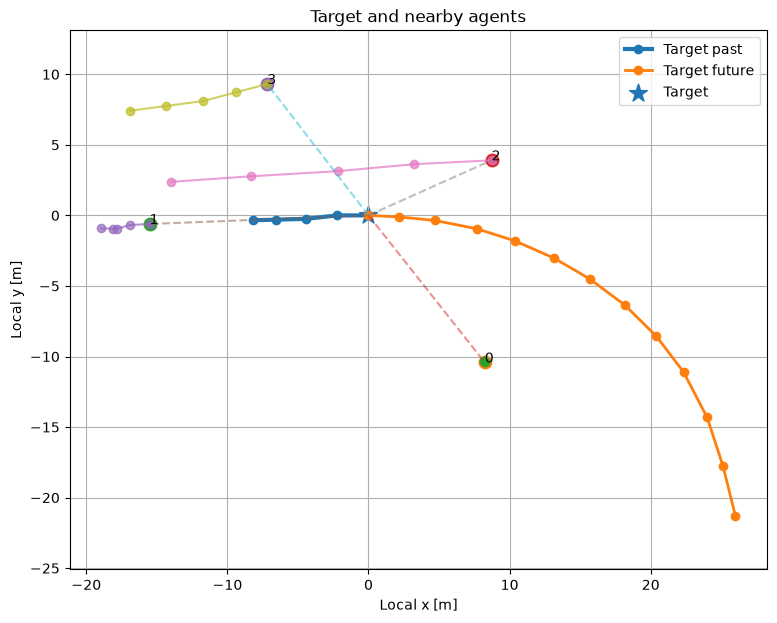

In [133]:
plt.figure(figsize=(9, 7))

# Target past
target_past = sample["past"]

plt.plot(
    target_past[:, 0],
    target_past[:, 1],
    marker="o",
    linewidth=3,
    label="Target past"
)

# Target future
target_future = sample["future"]

future_plot = np.vstack([
    [[0.0, 0.0]],
    target_future
])

plt.plot(
    future_plot[:, 0],
    future_plot[:, 1],
    marker="o",
    linewidth=2,
    label="Target future"
)

# Current target
plt.scatter(
    0,
    0,
    s=180,
    marker="*",
    label="Target"
)

# Neighbor histories
for i, neighbor in enumerate(neighbors):

    traj = neighbor["past"]

    plt.plot(
        traj[:, 0],
        traj[:, 1],
        marker="o",
        alpha=0.7
    )

    # current neighbor location
    current_neighbor = traj[-1]

    plt.scatter(
        current_neighbor[0],
        current_neighbor[1],
        s=80
    )

    # graph edge target -> neighbor
    plt.plot(
        [0, current_neighbor[0]],
        [0, current_neighbor[1]],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        current_neighbor[0],
        current_neighbor[1],
        str(i)
    )

plt.xlabel("Local x [m]")
plt.ylabel("Local y [m]")
plt.title("Target and nearby agents")

plt.axis("equal")
plt.grid()
plt.legend()

plt.show()